# Weighted ResNet-50 for Retinal OCT Disease Classification

This notebook implements a ResNet-50 model with class weighting for multiclass classification of retinal OCT images from the Kermany2018 dataset.

The model classifies OCT images into four categories: CNV, DME, DRUSEN, and NORMAL. Since the dataset is imbalanced, class weights are computed from the training distribution and applied during training to penalize errors in minority classes more strongly.

ResNet-50 is used as the baseline convolutional neural network. The experiment uses transfer learning with ImageNet pretrained weights, image resizing to 224×224 pixels, data augmentation, early stopping, model checkpointing, and evaluation with accuracy, precision, recall, F1-score, Macro F1-score, and a confusion matrix.

In [11]:
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

print("TensorFlow version:", tf.__version__)
print("GPUs disponibles:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.19.0
GPUs disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [12]:
DATA_DIR = "/kaggle/input/datasets/fabrizioravelli/retinal-oct-images-splitted"

train_dir = os.path.join(DATA_DIR, "training", "train")
val_dir = os.path.join(DATA_DIR, "training", "val")
test_dir = os.path.join(DATA_DIR, "test")

print("Train existe:", os.path.exists(train_dir))
print("Val existe:", os.path.exists(val_dir))
print("Test existe:", os.path.exists(test_dir))

print("Clases en train:", os.listdir(train_dir))

Train existe: True
Val existe: True
Test existe: True
Clases en train: ['DRUSEN', 'CNV', 'NORMAL', 'DME']


In [13]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
EPOCHS = 20

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

In [14]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

print("Clases detectadas:", class_names)
print("Número de clases:", NUM_CLASSES)

Found 61284 files belonging to 4 classes.
Found 7659 files belonging to 4 classes.
Found 7664 files belonging to 4 classes.
Clases detectadas: ['CNV', 'DME', 'DRUSEN', 'NORMAL']
Número de clases: 4


In [15]:
train_labels = []

for class_index, class_name in enumerate(class_names):
    class_path = os.path.join(train_dir, class_name)
    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]
    train_labels.extend([class_index] * len(image_files))

train_labels = np.array(train_labels)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_labels
)

class_weights = {
    i: weight for i, weight in enumerate(class_weights_array)
}

print("Class names:", class_names)
print("Class weights:", class_weights)

Class names: ['CNV', 'DME', 'DRUSEN', 'NORMAL']
Class weights: {0: np.float64(0.6053338601343342), 1: np.float64(1.743400091033227), 2: np.float64(2.4490089514066495), 3: np.float64(0.7320114667940755)}


In [16]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [17]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
], name="data_augmentation")

### Create Model

In [18]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

resnet50_weighted_model = models.Model(
    inputs,
    outputs,
    name="ResNet50_Weighted_Kermany2018"
)

resnet50_weighted_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

resnet50_weighted_model.summary()

Model: "ResNet50_Weighted_Kermany2018"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer_4[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 224, 224,  │          0 │ get_item_3[0][0], │
│                     │ 3)                │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 224, 224,  │          0 │ stack_1[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add_1[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 4)         │      8,196 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,595,908 (90.01 MB)

 Trainable params: 8,196 (32.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [19]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath="resnet50_weighted_best_model.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    CSVLogger("resnet50_weighted_training_log.csv")
]

In [20]:
start_time = time.time()

history = resnet50_weighted_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weights
)

end_time = time.time()
training_time = end_time - start_time

print(f"Tiempo total de entrenamiento: {training_time:.2f} segundos")
print(f"Tiempo total de entrenamiento: {training_time/60:.2f} minutos")

Epoch 1/20
1916/1916 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.5296 - loss: 1.1809
Epoch 1: val_loss improved from None to 0.52760, saving model to resnet50_weighted_best_model.keras

Epoch 1: finished saving model to resnet50_weighted_best_model.keras
1916/1916 ━━━━━━━━━━━━━━━━━━━━ 302s 153ms/step - accuracy: 0.6279 - loss: 0.9710 - val_accuracy: 0.8026 - val_loss: 0.5276
Epoch 2/20
1915/1916 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.7335 - loss: 0.7395
Epoch 2: val_loss improved from 0.52760 to 0.46455, saving model to resnet50_weighted_best_model.keras

Epoch 2: finished saving model to resnet50_weighted_best_model.keras
1916/1916 ━━━━━━━━━━━━━━━━━━━━ 290s 152ms/step - accuracy: 0.7413 - loss: 0.7183 - val_accuracy: 0.8240 - val_loss: 0.4645
Epoch 3/20
1915/1916 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.7648 - loss: 0.6616
Epoch 3: val_loss improved from 0.46455 to 0.43430, saving model to resnet50_weighted_best_model.keras

Epoch 3: finished saving model to res

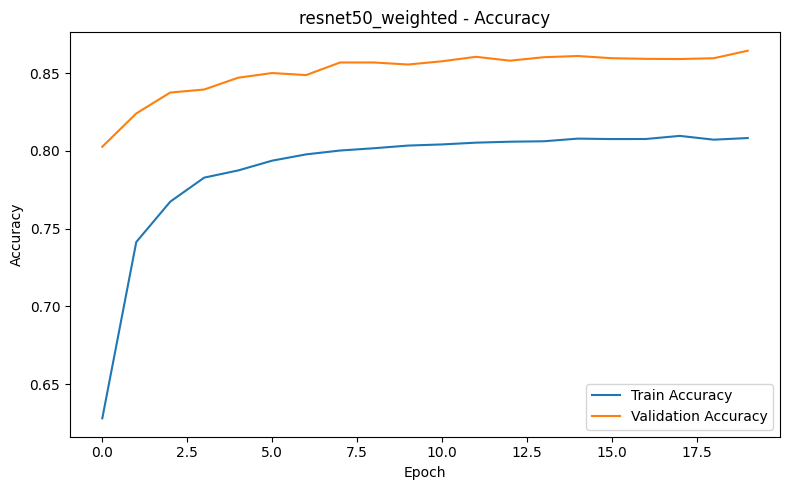

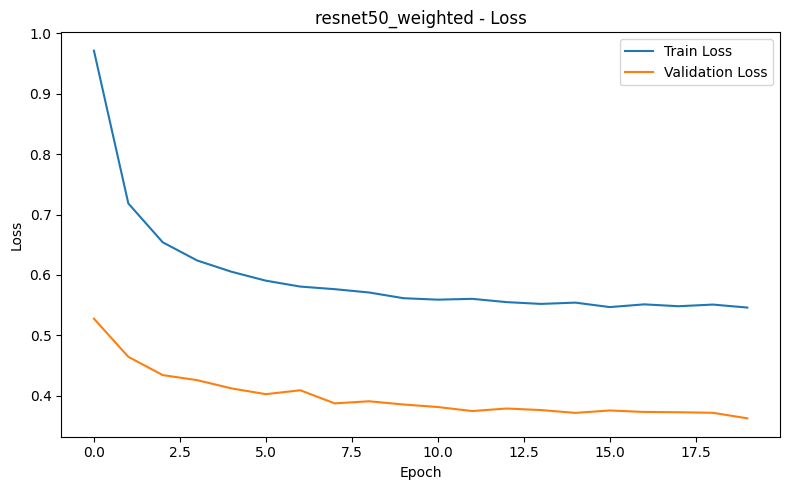

In [21]:
def plot_training_curves(history, model_name):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{model_name} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{model_name}_accuracy_curve.png", dpi=300)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"{model_name} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{model_name}_loss_curve.png", dpi=300)
    plt.show()

plot_training_curves(history, "resnet50_weighted")

In [22]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = resnet50_weighted_model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [23]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

df_report = pd.DataFrame(report).transpose()
df_report.to_csv("resnet50_weighted_classification_report.csv")

df_report

,precision,recall,f1-score,support
CNV,0.911765,0.910900,0.911332,3165.000000
DME,0.878156,0.727934,0.796020,1099.000000
DRUSEN,0.601071,0.573436,0.586928,783.000000
NORMAL,0.879044,0.955292,0.915583,2617.000000
accuracy,0.865344,0.865344,0.865344,0.865344
macro avg,0.817509,0.791891,0.802466,7664.000000
weighted avg,0.864030,0.865344,0.863105,7664.000000


In [24]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

         CNV       0.91      0.91      0.91      3165
         DME       0.88      0.73      0.80      1099
      DRUSEN       0.60      0.57      0.59       783
      NORMAL       0.88      0.96      0.92      2617

    accuracy                           0.87      7664
   macro avg       0.82      0.79      0.80      7664
weighted avg       0.86      0.87      0.86      7664



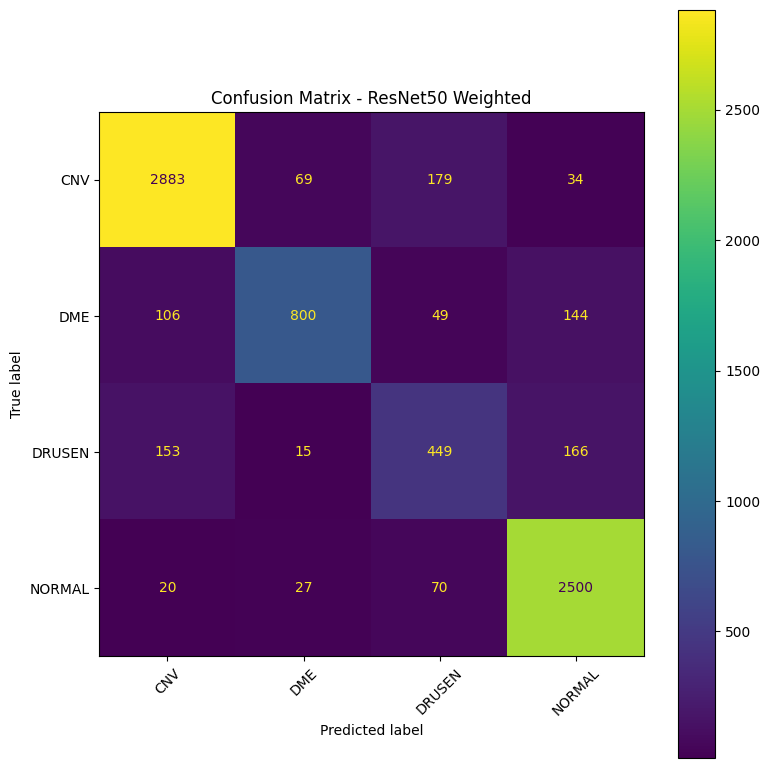

In [25]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, values_format="d")
plt.title("Confusion Matrix - ResNet50 Weighted")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("resnet50_weighted_confusion_matrix.png", dpi=300)
plt.show()

In [26]:
metrics = {
    "model": "ResNet50 Weighted",
    "accuracy": accuracy_score(y_true, y_pred),
    "precision_macro": precision_score(y_true, y_pred, average="macro"),
    "recall_macro": recall_score(y_true, y_pred, average="macro"),
    "f1_macro": f1_score(y_true, y_pred, average="macro"),
    "precision_weighted": precision_score(y_true, y_pred, average="weighted"),
    "recall_weighted": recall_score(y_true, y_pred, average="weighted"),
    "f1_weighted": f1_score(y_true, y_pred, average="weighted"),
    "training_time_seconds": training_time,
    "training_time_minutes": training_time / 60,
    "epochs_trained": len(history.history["loss"])
}

df_metrics = pd.DataFrame([metrics])
df_metrics.to_csv("resnet50_weighted_metrics_summary.csv", index=False)

df_metrics

,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,training_time_seconds,training_time_minutes,epochs_trained
0,ResNet50 Weighted,0.865344,0.817509,0.791891,0.802466,0.86403,0.865344,0.863105,5807.508955,96.791816,20


In [27]:
total_params = resnet50_weighted_model.count_params()

trainable_params = np.sum([
    np.prod(v.shape) for v in resnet50_weighted_model.trainable_weights
])

non_trainable_params = np.sum([
    np.prod(v.shape) for v in resnet50_weighted_model.non_trainable_weights
])

params_summary = pd.DataFrame([{
    "model": "ResNet50 Weighted",
    "total_params": total_params,
    "trainable_params": trainable_params,
    "non_trainable_params": non_trainable_params
}])

params_summary.to_csv("resnet50_weighted_params_summary.csv", index=False)
params_summary

,model,total_params,trainable_params,non_trainable_params
0,ResNet50 Weighted,23595908,8196,23587712
